# Phase 2: Cleaning and Exploratory Data Analysis

Goal:
- Clean the dataset for modeling
- Understand important distributions and category codes
- Explore relationships between features and default
- Identify preprocessing decisions for the baseline model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_excel("/Users/jacobcheng/Projects/credit_risk_project/data/raw/credit_card_clients_raw.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df = df.rename(columns={"default payment next month" : "default_next_month"})
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
target_col = "default_next_month"

In [7]:
df = df.drop(columns=["ID"])
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


"ID" was removed as it's value is an identifier and does aid us with predictions.

In [8]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
ordinal_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
payment_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
numeric_cols = ["LIMIT_BAL", "AGE"] + bill_cols + payment_cols

In [9]:
print("Categorical:", categorical_cols)
print("Ordinal:", ordinal_cols)
print("Numeric:", numeric_cols[:5], "...", numeric_cols[-3:])

Categorical: ['SEX', 'EDUCATION', 'MARRIAGE']
Ordinal: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numeric: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3'] ... ['PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [10]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


Some categorical variables contain coded integer values rather than labels. These need to be interpreted carefully before modeling. Unusual or low-frequency codes may need regrouping in a later preprocessing step.

In [11]:
for col in ordinal_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int6

The repayment variables appear to be ordinal, so the larger values will represent worse repayment behavior and be strong predictors of default risk.

In [12]:
for col in ordinal_cols:
    print(f"\nDefault rate by {col}")
    print(df.groupby(col)[target_col].mean().sort_index())


Default rate by PAY_0
PAY_0
-2    0.132294
-1    0.167781
 0    0.128113
 1    0.339479
 2    0.691414
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: default_next_month, dtype: float64

Default rate by PAY_2
PAY_2
-2    0.182708
-1    0.159669
 0    0.159123
 1    0.178571
 2    0.556150
 3    0.616564
 4    0.505051
 5    0.600000
 6    0.750000
 7    0.600000
 8    0.000000
Name: default_next_month, dtype: float64

Default rate by PAY_3
PAY_3
-2    0.185312
-1    0.155945
 0    0.174512
 1    0.250000
 2    0.515580
 3    0.575000
 4    0.578947
 5    0.571429
 6    0.608696
 7    0.814815
 8    0.666667
Name: default_next_month, dtype: float64

Default rate by PAY_4
PAY_4
-2    0.192502
-1    0.158959
 0    0.183288
 1    0.500000
 2    0.523267
 3    0.611111
 4    0.666667
 5    0.514286
 6    0.400000
 7    0.827586
 8    0.500000
Name: default_next_month, dtype: float64

Default rate by PAY_5
PAY_5
-2    0.196876
-1    0.161943
 

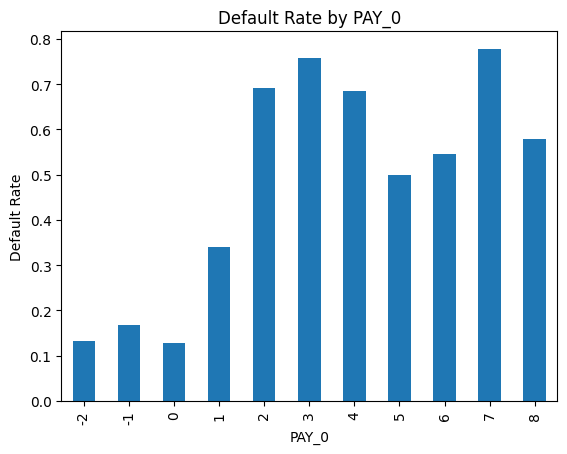

In [15]:
pay0_default_rate = df.groupby("PAY_0")[target_col].mean().sort_index()
pay0_default_rate.plot(kind="bar")
plt.title("Default Rate by PAY_0")
plt.xlabel("PAY_0")
plt.ylabel("Default Rate")
plt.show()

Repayment status at the current month appears to strongly associate with default risk. This aligns with the expectation that bad payment history is informative of predicting defaults.

In [16]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
